In [1]:
import json

import logomaker as lm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyliftover
import seaborn as sns
from pyfaidx import Fasta
from scipy.stats import chi2_contingency

from analysis_functions import (
                        calculate_chi2_p_values,
                        filter_and_convert_to_list,
                        check_ref,
                        get_codon_info,
                        get_context
                    )

## 1. Separate variants by pathogenicity value

Create dataframes for pathogenic/benign variants based on frequency.

* **pathogenic**  
 Cutoff in AC < 2. Additionally, intersect with the options in ClinVar and add pathogenic/likely pathogenic variants that are missing in GnomAD v.4, but are in ClinVar.

* **benign**  
 AC cut-off >= 2 (according to recent ACGS guidelines, BS2 criterion). In this case, we may have many autosomal recessive variants left, so let’s remove them. To do this, compare the resulting dataframe with benign ClinVar variants and remove all intersections with registered P/LP variants.

In [2]:
nmd_undergo_df = pd.read_csv("data/nmd_undergo_df.csv")

In [3]:
pat_nmd_undergo = nmd_undergo_df.query('AC < 2')

In [4]:
ben_nmd_undergo = nmd_undergo_df.query('AC >= 2')

### Remove all pathogenic Clinvar variants from benign dataframe

Merge `clinvar_nmd_undergo_df` and `ben_nmd_undergo` dataframes, remove all intersections by `CHROM`, `POS`, `REF`, `ALT`, and then remove the remainder of `clinvar_nmd_undergo_df` (i.e. remove all rows that do not have an empty `CLNSIG` column).

In [5]:
clinvar_nmd_undergo_df = pd.read_csv("data/clinvar_nmd_undergo_df.csv")
clinvar_nmd_undergo = clinvar_nmd_undergo_df.rename(columns={'Feature': 'Canonical_transcript'})

In [6]:
merged_clinvar_and_ben_undergo = pd.concat([ben_nmd_undergo, clinvar_nmd_undergo], ignore_index=True)
merged_clinvar_and_ben_undergo

,CHROM,POS,rsID,REF,ALT,Impact,Consequence,Gene_symbol,Canonical_transcript,cDNA_position,...,CLNSIG,CLNVC,GENEINFO,CLNREVSTAT,MC,SYMBOL,Gene,Feature_type,BIOTYPE,CANONICAL
0,chr1,70292486,.,T,A,HIGH,stop_gained,ANKRD13C,ENST00000370944,1431,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,chr1,70300868,.,G,A,HIGH,stop_gained,ANKRD13C,ENST00000370944,1131,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chr1,70306276,rs1680585031,G,A,HIGH,stop_gained,ANKRD13C,ENST00000370944,1038,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,chr1,70315504,rs1037402044,G,A,HIGH,stop_gained,ANKRD13C,ENST00000370944,954,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,chr1,93896814,.,G,C,HIGH,stop_gained,GCLM,ENST00000370238,611,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8268,chr22,50721740,NaN,C,T,NaN,stop_gained,NaN,ENST00000262795,3958,...,Pathogenic,single_nucleotide_variant,SHANK3:85358,"criteria_provided,_single_submitter",SO:0001587|nonsense,SHANK3,ENSG00000251322,Transcript,protein_coding,YES
8269,chr22,50722004,NaN,G,T,NaN,stop_gained,NaN,ENST00000262795,4222,...,Pathogenic,single_nucleotide_variant,SHANK3:85358,"criteria_provided,_single_submitter",SO:0001587|nonsense,SHANK3,ENSG00000251322,Transcript,protein_coding,YES
8270,chr22,50722235,NaN,C,T,NaN,stop_gained,NaN,ENST00000262795,4453,...,Pathogenic/Likely_pathogenic,single_nucleotide_variant,SHANK3:85358,"criteria_provided,_multiple_submitters,_no_con...",SO:0001587|nonsense,SHANK3,ENSG00000251322,Transcript,protein_coding,YES
8271,chr22,50722255,NaN,G,A,NaN,stop_gained,NaN,ENST00000262795,4473,...,Pathogenic,single_nucleotide_variant,SHANK3:85358,"criteria_provided,_single_submitter",SO:0001587|nonsense,SHANK3,ENSG00000251322,Transcript,protein_coding,YES


In [7]:
# remove duplicates
ben_nmd_undergo_filtered = merged_clinvar_and_ben_undergo.drop_duplicates(subset=['CHROM', 'POS', 'REF', 'ALT'], keep=False)

In [8]:
# remove the Clinvar df
ben_nmd_undergo_filtered = ben_nmd_undergo_filtered[~ben_nmd_undergo_filtered['CLNSIG'].notna()]

In [9]:
ben_nmd_undergo_filtered.columns

Index(['CHROM', 'POS', 'rsID', 'REF', 'ALT', 'Impact', 'Consequence',
       'Gene_symbol', 'Canonical_transcript', 'cDNA_position', 'LoF',
       'LoF_flag', 'LoF_filter', 'AC', 'LOEUF', 'pext', 'NMD_escape', 'ID',
       'CLNSIG', 'CLNVC', 'GENEINFO', 'CLNREVSTAT', 'MC', 'SYMBOL', 'Gene',
       'Feature_type', 'BIOTYPE', 'CANONICAL'],
      dtype='object')

Remove unnecessary columns left after Clinvar.

In [10]:
ben_nmd_undergo_filtered = ben_nmd_undergo_filtered.drop(columns=['ID', 'CLNSIG', 'CLNVC', 'CLNREVSTAT', 'GENEINFO', 'MC', 'SYMBOL', 
                                                'Gene', 'Feature_type', 'BIOTYPE', 'CANONICAL'])
ben_nmd_undergo_filtered

,CHROM,POS,rsID,REF,ALT,Impact,Consequence,Gene_symbol,Canonical_transcript,cDNA_position,LoF,LoF_flag,LoF_filter,AC,LOEUF,pext,NMD_escape
0,chr1,70292486,.,T,A,HIGH,stop_gained,ANKRD13C,ENST00000370944,1431,HC,NaN,NaN,4.0,0.248,0.897161,NO
1,chr1,70300868,.,G,A,HIGH,stop_gained,ANKRD13C,ENST00000370944,1131,HC,NaN,NaN,3.0,0.248,0.897161,NO
2,chr1,70306276,rs1680585031,G,A,HIGH,stop_gained,ANKRD13C,ENST00000370944,1038,HC,NaN,NaN,2.0,0.248,0.897161,NO
3,chr1,70315504,rs1037402044,G,A,HIGH,stop_gained,ANKRD13C,ENST00000370944,954,HC,NaN,NaN,2.0,0.248,0.897161,NO
4,chr1,93896814,.,G,C,HIGH,stop_gained,GCLM,ENST00000370238,611,HC,NaN,NaN,2.0,0.216,0.650657,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3317,chr22,50600868,.,C,A,HIGH,stop_gained,MAPK8IP2,ENST00000329492,76,HC,NaN,NaN,2.0,0.100,0.775794,NO
3318,chr22,50720238,.,C,A,HIGH,stop_gained,SHANK3,ENST00000262795,2456,HC,NaN,NaN,3.0,0.123,1.000000,NO
3319,chr22,50720534,.,G,T,HIGH,stop_gained,SHANK3,ENST00000262795,2752,HC,NaN,NaN,2.0,0.123,1.000000,NO
3320,chr22,50721521,.,G,T,HIGH,stop_gained,SHANK3,ENST00000262795,3739,HC,NaN,NaN,5.0,0.123,1.000000,NO


Before filtering:

In [11]:
ben_nmd_undergo.shape

(3322, 17)

Add position in codon for each variant.

In [12]:
ben_nmd_undergo_filtered['cDNA_position'] = ben_nmd_undergo_filtered['cDNA_position'].astype(int)

ben_nmd_undergo_filtered['Codon_position'] = np.where(ben_nmd_undergo_filtered['cDNA_position'] % 3 == 1, 1,
                                           np.where(ben_nmd_undergo_filtered['cDNA_position'] % 3 == 2, 2, 
                                                    3))

ben_nmd_undergo_filtered

,CHROM,POS,rsID,REF,ALT,Impact,Consequence,Gene_symbol,Canonical_transcript,cDNA_position,LoF,LoF_flag,LoF_filter,AC,LOEUF,pext,NMD_escape,Codon_position
0,chr1,70292486,.,T,A,HIGH,stop_gained,ANKRD13C,ENST00000370944,1431,HC,NaN,NaN,4.0,0.248,0.897161,NO,3
1,chr1,70300868,.,G,A,HIGH,stop_gained,ANKRD13C,ENST00000370944,1131,HC,NaN,NaN,3.0,0.248,0.897161,NO,3
2,chr1,70306276,rs1680585031,G,A,HIGH,stop_gained,ANKRD13C,ENST00000370944,1038,HC,NaN,NaN,2.0,0.248,0.897161,NO,3
3,chr1,70315504,rs1037402044,G,A,HIGH,stop_gained,ANKRD13C,ENST00000370944,954,HC,NaN,NaN,2.0,0.248,0.897161,NO,3
4,chr1,93896814,.,G,C,HIGH,stop_gained,GCLM,ENST00000370238,611,HC,NaN,NaN,2.0,0.216,0.650657,NO,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3317,chr22,50600868,.,C,A,HIGH,stop_gained,MAPK8IP2,ENST00000329492,76,HC,NaN,NaN,2.0,0.100,0.775794,NO,1
3318,chr22,50720238,.,C,A,HIGH,stop_gained,SHANK3,ENST00000262795,2456,HC,NaN,NaN,3.0,0.123,1.000000,NO,2
3319,chr22,50720534,.,G,T,HIGH,stop_gained,SHANK3,ENST00000262795,2752,HC,NaN,NaN,2.0,0.123,1.000000,NO,1
3320,chr22,50721521,.,G,T,HIGH,stop_gained,SHANK3,ENST00000262795,3739,HC,NaN,NaN,5.0,0.123,1.000000,NO,1


**The dataframe with benign variants is ready.**

In [13]:
pat_nmd_undergo_filtered = pat_nmd_undergo.copy()

**The dataframe with pathogenic variants is ready.**

## 2. Balance dataframes

In both dataframes, we will leave only those genes that are found in both `ben_nmd_undergo_filtered` and `pat_nmd_undergo_filtered`, and also equalize the number of variants in each gene.

In [14]:
unique_genes_ben = ben_nmd_undergo_filtered['Gene_symbol'].unique()
unique_genes_pat = pat_nmd_undergo_filtered['Gene_symbol'].unique()
intersected_genes = np.intersect1d(unique_genes_pat, unique_genes_ben)

print("Unique genes in pat dataframe:", len(unique_genes_pat))
print("Unique genes in ben dataframe:", len(unique_genes_ben))
print("Intersected genes:", len(intersected_genes))


Unique genes in pat dataframe: 1303
Unique genes in ben dataframe: 870
Intersected genes: 847


In [15]:
common_genes = set(unique_genes_ben) & set(unique_genes_pat)

ben_nmd_undergo_filtered = ben_nmd_undergo_filtered[ben_nmd_undergo_filtered['Gene_symbol'].isin(common_genes)]
pat_nmd_undergo_filtered = pat_nmd_undergo_filtered[pat_nmd_undergo_filtered['Gene_symbol'].isin(common_genes)]

In [16]:
unique_genes_pat = pat_nmd_undergo_filtered['Gene_symbol'].unique()
unique_genes_ben = ben_nmd_undergo_filtered['Gene_symbol'].unique()

intersected_genes = np.intersect1d(unique_genes_pat, unique_genes_ben)

print("Unique genes in pat dataframe:", len(unique_genes_pat))
print("Unique genes in ben dataframe:", len(unique_genes_ben))
print("Intersected genes:", len(intersected_genes))

Unique genes in pat dataframe: 847
Unique genes in ben dataframe: 847
Intersected genes: 847


In [17]:
count_pat = pat_nmd_undergo_filtered['Gene_symbol'].value_counts()
count_ben = ben_nmd_undergo_filtered['Gene_symbol'].value_counts()

min_counts = pd.concat([count_pat, count_ben], axis=1).min(axis=1)

pat_nmd_undergo_final = pd.concat([
    pat_nmd_undergo_filtered[pat_nmd_undergo_filtered['Gene_symbol'] == gene].sample(n=min_count, random_state=42) \
    for gene, min_count in min_counts.items()
])

ben_nmd_undergo_final = pd.concat([
    ben_nmd_undergo_filtered[ben_nmd_undergo_filtered['Gene_symbol'] == gene].sample(n=min_count, random_state=42) \
    for gene, min_count in min_counts.items()
])


In [18]:
pat_nmd_undergo_final.shape == ben_nmd_undergo_final.shape

False

In [19]:
pat_nmd_undergo_final['Gene_symbol'].nunique() == ben_nmd_undergo_final['Gene_symbol'].nunique()

True

In [20]:
pat_nmd_undergo_final['Gene_symbol'].value_counts().sum() == ben_nmd_undergo_final['Gene_symbol'].value_counts().sum()

True

In [21]:
pat_nmd_undergo_final['Gene_symbol'].nunique()

847

Dataframes are now balanced by genes and number of variants.

## 3. Get sequence context

Write the context in the corresponding column of the dataframe.

File `gencode.v45.transcripts.fa.gz` can be downloaded from the GENCODE database (https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_46/gencode.v46.transcripts.fa.gz).

In [22]:
transcript_fasta = Fasta("gencode_data/gencode.v45.transcripts.fa.gz", key_function = lambda x: x.split('.')[0])

Get contexts.

In [23]:
get_context(ben_nmd_undergo_final, transcript_fasta, 13, 12)

'Contexts have been added to the dataframe!'

In [24]:
get_context(pat_nmd_undergo_final, transcript_fasta, 13, 12)

'Contexts have been added to the dataframe!'

In [25]:
pat_nmd_undergo_final['Strand'] = pat_nmd_undergo_final.apply(check_ref, axis=1, transcript_fasta=transcript_fasta)
pat_nmd_undergo_final['Strand'].value_counts()

Strand
+              1581
-              1432
Not_defined       2
Name: count, dtype: int64

In [26]:
ben_nmd_undergo_final['Strand'] = ben_nmd_undergo_final.apply(check_ref, axis=1, transcript_fasta=transcript_fasta)
ben_nmd_undergo_final['Strand'].value_counts()

Strand
+              1581
-              1433
Not_defined       1
Name: count, dtype: int64

In [27]:
pat_nmd_undergo_final = pat_nmd_undergo_final[pat_nmd_undergo_final['Strand'] != 'Not_defined']
ben_nmd_undergo_final = ben_nmd_undergo_final[ben_nmd_undergo_final['Strand'] != 'Not_defined']

## 4. Get variant codons information

In [28]:
pat_nmd_undergo_final[['Codon_position', 'Codon', 'Stop_Codon']] = pat_nmd_undergo_final.apply(lambda row: pd.Series(get_codon_info(row)), axis=1)
pat_nmd_undergo_final['Codon_position'].value_counts()

Codon_position
1          1906
3           597
2           509
No_stop       1
Name: count, dtype: int64

In [29]:
pat_nmd_undergo_final['Codon_change'] = list(zip(pat_nmd_undergo_final['Codon'], pat_nmd_undergo_final['Stop_Codon']))
pat_nmd_undergo_final['Codon_change'].value_counts(normalize=True) * 100

Codon_change
(CAG, TAG)        20.876203
(CGA, TGA)        11.184866
(GAG, TAG)         9.459011
(GAA, TAA)         7.600398
(CAA, TAA)         6.505144
(TGG, TGA)         5.044806
(TGG, TAG)         4.215068
(TAC, TAA)         4.148689
(TAC, TAG)         3.816794
(TCA, TAA)         3.783604
(TCA, TGA)         3.352141
(GGA, TGA)         2.821109
(TGC, TGA)         2.787919
(TCG, TAG)         2.389645
(AAG, TAG)         2.190508
(AAA, TAA)         1.858613
(TAT, TAA)         1.559907
(TTA, TGA)         1.493528
(TAT, TAG)         1.294391
(TGT, TGA)         1.161633
(TTG, TAG)         0.962496
(AGA, TGA)         0.763359
(TTA, TAA)         0.696980
(No_stop, nan)     0.033190
Name: proportion, dtype: float64

In [30]:
ben_nmd_undergo_final[['Codon_position', 'Codon', 'Stop_Codon']] = ben_nmd_undergo_final.apply(lambda row: pd.Series(get_codon_info(row)), axis=1)
ben_nmd_undergo_final['Codon_position'].value_counts()

Codon_position
1          2389
3           322
2           301
No_stop       2
Name: count, dtype: int64

In [31]:
ben_nmd_undergo_final['Codon_change'] = list(zip(ben_nmd_undergo_final['Codon'], ben_nmd_undergo_final['Stop_Codon']))
ben_nmd_undergo_final['Codon_change'].value_counts(normalize=True) * 100

Codon_change
(CGA, TGA)        50.763106
(CAG, TAG)        12.641009
(GAG, TAG)         5.507631
(GAA, TAA)         4.047777
(TGG, TGA)         3.085601
(TCA, TAA)         3.019244
(CAA, TAA)         2.986065
(TGG, TAG)         2.455209
(TAC, TAG)         2.322495
(TAC, TAA)         2.189781
(TCA, TGA)         1.725282
(TGC, TGA)         1.625747
(TCG, TAG)         1.592568
(GGA, TGA)         1.293962
(AAA, TAA)         0.962177
(AAG, TAG)         0.796284
(TAT, TAA)         0.663570
(TAT, TAG)         0.597213
(TTA, TGA)         0.464499
(TTA, TAA)         0.364964
(TTG, TAG)         0.364964
(AGA, TGA)         0.265428
(TGT, TGA)         0.199071
(No_stop, nan)     0.066357
Name: proportion, dtype: float64

In [32]:
pat_nmd_undergo_final = pat_nmd_undergo_final[pat_nmd_undergo_final['Codon_position'] != 'No_stop']
ben_nmd_undergo_final = ben_nmd_undergo_final[ben_nmd_undergo_final['Codon_position'] != 'No_stop']

How stop codons are distributed:

In [33]:
pat_stop_codon_counts = pat_nmd_undergo_final['Stop_Codon'].value_counts()
ben_stop_codon_counts = ben_nmd_undergo_final['Stop_Codon'].value_counts()

stop_codon_contingency = pd.DataFrame({
    'Pathogenic': pat_stop_codon_counts,
    'Benign': ben_stop_codon_counts
})

chi2, p, dof, expected = chi2_contingency(stop_codon_contingency)

print(f'Chi-squared: {chi2}')
print(f'p-value: {p}')

Chi-squared: 582.0438061096656
p-value: 4.081251801335006e-127


In [34]:
pat_stop_codon_percent = pat_nmd_undergo_final['Stop_Codon'].value_counts(normalize=True) * 100
ben_stop_codon_percent = ben_nmd_undergo_final['Stop_Codon'].value_counts(normalize=True) * 100

stop_codon_df_undergo = pd.DataFrame({
    'Pathogenic': pat_stop_codon_percent,
    'Benign': ben_stop_codon_percent
}).reset_index().rename(columns={'index': 'Stop_Codon'})

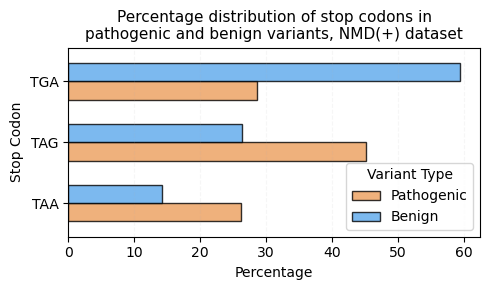

In [35]:
colors = ['#EB9E5B', '#5BA8EB']

fig, ax = plt.subplots(figsize=(5, 3))

stop_codon_df_undergo.plot(kind='barh', x='Stop_Codon', width=0.6, alpha=0.8, edgecolor='black', linewidth=1, color=colors, ax=ax)
plt.title('Percentage distribution of stop codons in\npathogenic and benign variants, NMD(+) dataset', fontsize=11)
plt.xlabel('Percentage', fontsize=10)
plt.ylabel('Stop Codon', fontsize=10)
plt.grid(True, axis='x', linestyle='--', alpha=0.1)
plt.legend(title='Variant Type', fontsize=10)
plt.tight_layout()

#plt.savefig('images/horizontal_bar_plot_stops_distr_nmd_undergo.png', dpi=300)

plt.show()

Divide dataframes depending on codon position.

In [36]:
ben_nmd_undergo_final_1 = ben_nmd_undergo_final.loc[ben_nmd_undergo_final['Codon_position'] == 1].copy()
ben_nmd_undergo_final_2 = ben_nmd_undergo_final.loc[ben_nmd_undergo_final['Codon_position'] == 2].copy()
ben_nmd_undergo_final_3 = ben_nmd_undergo_final.loc[ben_nmd_undergo_final['Codon_position'] == 3].copy()

In [37]:
pat_nmd_undergo_final_1 = pat_nmd_undergo_final.loc[pat_nmd_undergo_final['Codon_position'] == 1].copy()
pat_nmd_undergo_final_2 = pat_nmd_undergo_final.loc[pat_nmd_undergo_final['Codon_position'] == 2].copy()
pat_nmd_undergo_final_3 = pat_nmd_undergo_final.loc[pat_nmd_undergo_final['Codon_position'] == 3].copy()

## 5. Visualize the distribution of cDNA positions relative to the transcripts boundaries

Get a dictionary with transcript lengths and write the % location of the variant into a dataframe.

In [38]:
transcript_lengths = {}
for key in transcript_fasta.keys():
    transcript_lengths[key] = len(transcript_fasta[key])

In [39]:
pat_nmd_undergo_final['Percent_position'] = pat_nmd_undergo_final \
    .apply(lambda row: (row['cDNA_position'] / transcript_lengths[row['Canonical_transcript']]) * 100, axis=1)

ben_nmd_undergo_final['Percent_position'] = ben_nmd_undergo_final \
    .apply(lambda row: (row['cDNA_position'] / transcript_lengths[row['Canonical_transcript']]) * 100, axis=1)

Visualize the distribution of variants.

In [40]:
pat_nmd_undergo_final_sorted = pat_nmd_undergo_final.copy()
pat_nmd_undergo_final_sorted['CHROM'] = pat_nmd_undergo_final_sorted['CHROM'].str.extract(r'(\d+)')
pat_nmd_undergo_final_sorted = pat_nmd_undergo_final_sorted.sort_values(by='CHROM', key=lambda x: x.astype(int))

In [41]:
ben_nmd_undergo_final_sorted = ben_nmd_undergo_final.copy()
ben_nmd_undergo_final_sorted['CHROM'] = ben_nmd_undergo_final_sorted['CHROM'].str.extract(r'(\d+)')
ben_nmd_undergo_final_sorted = ben_nmd_undergo_final_sorted.sort_values(by='CHROM', key=lambda x: x.astype(int))

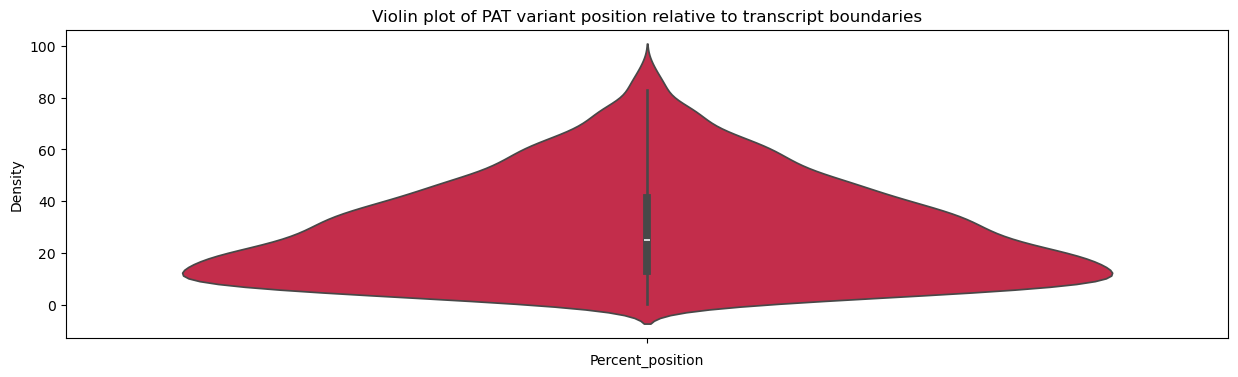

In [42]:
plt.figure(figsize=(15, 4))
sns.violinplot(y='Percent_position', data=pat_nmd_undergo_final_sorted, color='crimson')
plt.title('Violin plot of PAT variant position relative to transcript boundaries')
plt.xlabel('Percent_position')
plt.ylabel('Density')
plt.show()

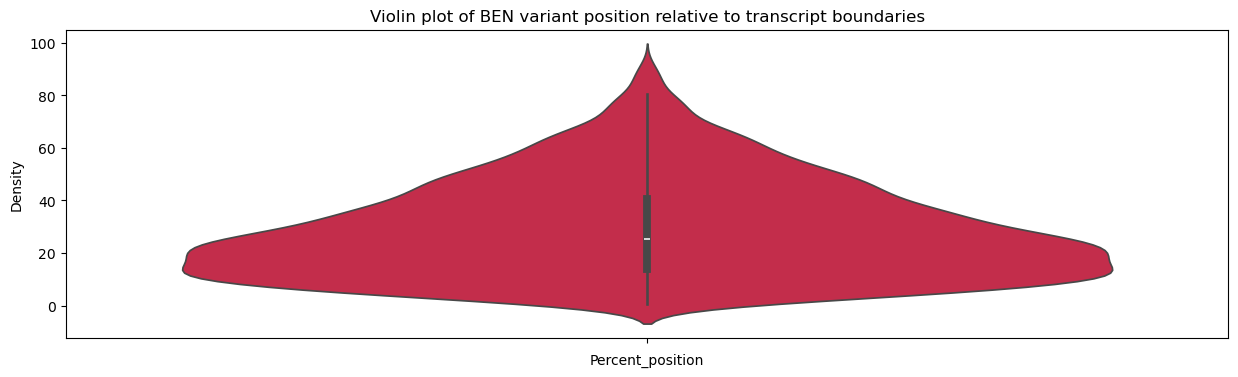

In [43]:
plt.figure(figsize=(15, 4))
sns.violinplot(y='Percent_position', data=ben_nmd_undergo_final_sorted, color='crimson')
plt.title('Violin plot of BEN variant position relative to transcript boundaries')
plt.xlabel('Percent_position')
plt.ylabel('Density')
plt.show()

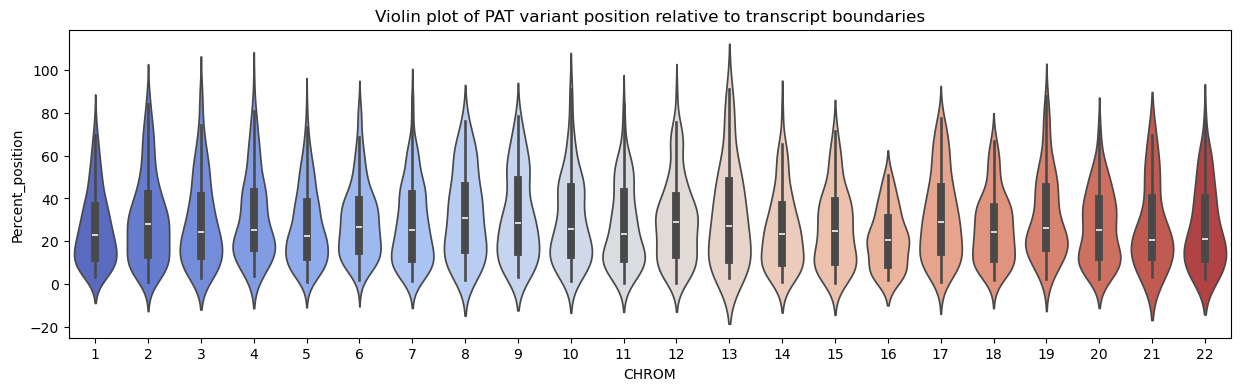

In [44]:
plt.figure(figsize=(15, 4))
sns.violinplot(x='CHROM', y='Percent_position', data=pat_nmd_undergo_final_sorted, hue='CHROM', palette='coolwarm', legend=False)
plt.title('Violin plot of PAT variant position relative to transcript boundaries')
plt.xlabel('CHROM')
plt.ylabel('Percent_position')
plt.show()

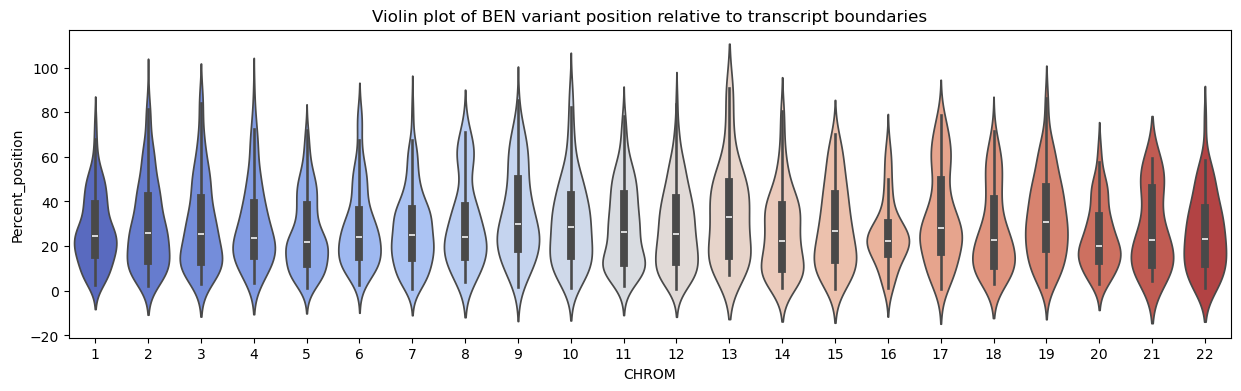

In [45]:
plt.figure(figsize=(15, 4))
sns.violinplot(x='CHROM', y='Percent_position', data=ben_nmd_undergo_final_sorted, hue='CHROM', palette='coolwarm', legend=False)
plt.title('Violin plot of BEN variant position relative to transcript boundaries')
plt.xlabel('CHROM')
plt.ylabel('Percent_position')
plt.show()

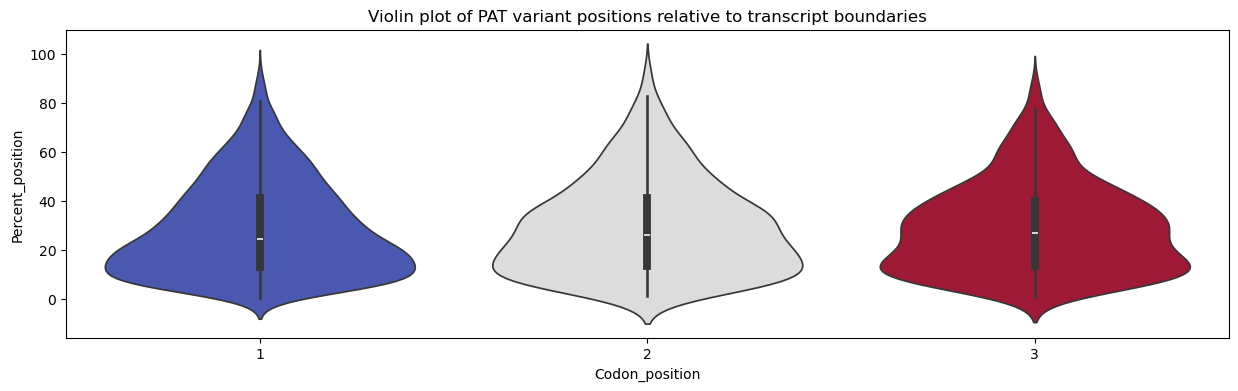

In [46]:
plt.figure(figsize=(15, 4))
sns.violinplot(x='Codon_position', y='Percent_position', data=pat_nmd_undergo_final_sorted, hue='Codon_position', palette='coolwarm', legend=False)
plt.title('Violin plot of PAT variant positions relative to transcript boundaries')
plt.xlabel('Codon_position')
plt.ylabel('Percent_position')
plt.show()

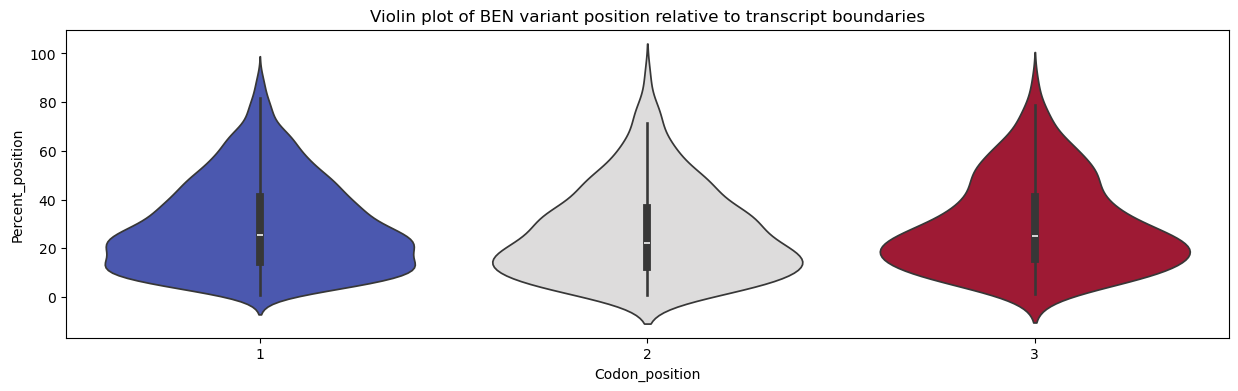

In [47]:
plt.figure(figsize=(15, 4))
sns.violinplot(x='Codon_position', y='Percent_position', data=ben_nmd_undergo_final_sorted, hue='Codon_position', palette='coolwarm', legend=False)
plt.title('Violin plot of BEN variant position relative to transcript boundaries')
plt.xlabel('Codon_position')
plt.ylabel('Percent_position')
plt.show()

## 6. Build a sequence logo

In [48]:
filtered_context_ben_1 = filter_and_convert_to_list(ben_nmd_undergo_final_1['Context'])
filtered_context_ben_2 = filter_and_convert_to_list(ben_nmd_undergo_final_2['Context'])
filtered_context_ben_3 = filter_and_convert_to_list(ben_nmd_undergo_final_3['Context'])

In [49]:
filtered_context_pat_1 = filter_and_convert_to_list(pat_nmd_undergo_final_1['Context'])
filtered_context_pat_2 = filter_and_convert_to_list(pat_nmd_undergo_final_2['Context'])
filtered_context_pat_3 = filter_and_convert_to_list(pat_nmd_undergo_final_3['Context'])

In [50]:
custom_colors = {
    'A': '#E55D3F',  # red
    'C': '#53B943',  # green
    'G': '#4F64C7',  # blue
    'T': '#F5B846'   # yellow
}

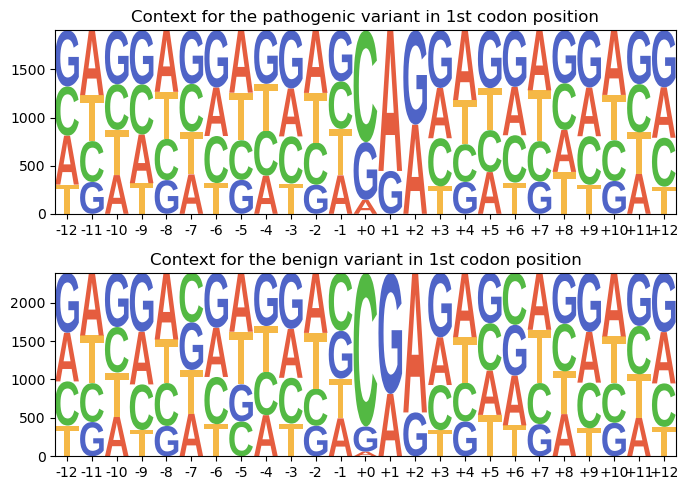

In [51]:
counts_mat_pat_1 = lm.alignment_to_matrix(filtered_context_pat_1)
counts_mat_ben_1 = lm.alignment_to_matrix(filtered_context_ben_1)

fig, axs = plt.subplots(2, 1, figsize=(7, 5))

pat_logo = lm.Logo(counts_mat_pat_1, font_name='Liberation Sans', color_scheme=custom_colors, ax=axs[0])
pat_logo.style_xticks()
pat_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
pat_logo.ax.set_title('Context for the pathogenic variant in 1st codon position')
pat_logo.draw()

ben_logo = lm.Logo(counts_mat_ben_1, font_name='Liberation Sans', color_scheme=custom_colors, ax=axs[1])
ben_logo.style_xticks()
ben_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
ben_logo.ax.set_title('Context for the benign variant in 1st codon position')
ben_logo.draw()

plt.tight_layout()
plt.savefig('images/1st_pos_context_nmd_undergo_wo_in_clinvar.png', bbox_inches='tight')

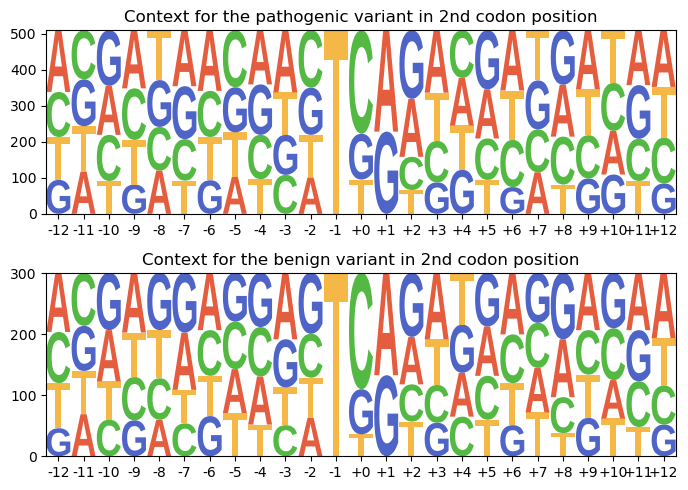

In [52]:
counts_mat_pat_2 = lm.alignment_to_matrix(filtered_context_pat_2)
counts_mat_ben_2 = lm.alignment_to_matrix(filtered_context_ben_2)

fig, axs = plt.subplots(2, 1, figsize=(7, 5))

pat_logo = lm.Logo(counts_mat_pat_2, font_name='Liberation Sans', color_scheme=custom_colors, ax=axs[0])
pat_logo.style_xticks()
pat_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
pat_logo.ax.set_title('Context for the pathogenic variant in 2nd codon position')
pat_logo.draw()

ben_logo = lm.Logo(counts_mat_ben_2, font_name='Liberation Sans', color_scheme=custom_colors, ax=axs[1])
ben_logo.style_xticks()
ben_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
ben_logo.ax.set_title('Context for the benign variant in 2nd codon position')
ben_logo.draw()

plt.tight_layout()
plt.savefig('images/2nd_pos_context_nmd_undergo_wo_in_clinvar.png', bbox_inches='tight')

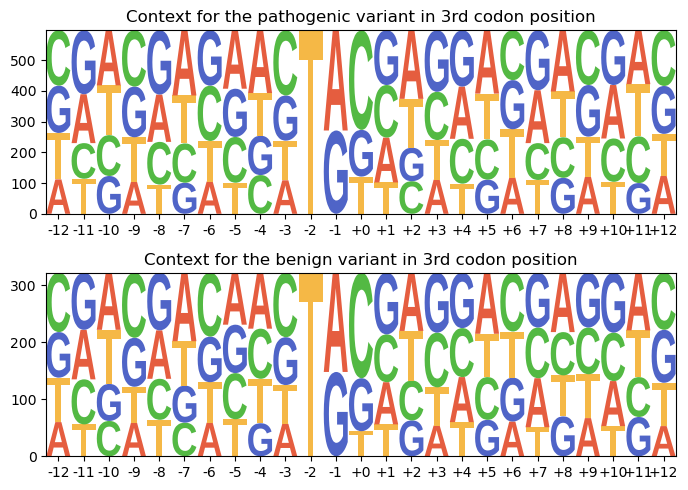

In [53]:
counts_mat_pat_3 = lm.alignment_to_matrix(filtered_context_pat_3)
counts_mat_ben_3 = lm.alignment_to_matrix(filtered_context_ben_3)

fig, axs = plt.subplots(2, 1, figsize=(7, 5))

pat_logo = lm.Logo(counts_mat_pat_3, font_name='Liberation Sans', color_scheme=custom_colors, ax=axs[0])
pat_logo.style_xticks()
pat_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
pat_logo.ax.set_title('Context for the pathogenic variant in 3rd codon position')
pat_logo.draw()

ben_logo = lm.Logo(counts_mat_ben_3, font_name='Liberation Sans', color_scheme=custom_colors, ax=axs[1])
ben_logo.style_xticks()
ben_logo.ax.set_xticklabels('%+d'%x for x in range(-12, 13))
ben_logo.ax.set_title('Context for the benign variant in 3rd codon position')
ben_logo.draw()

plt.tight_layout()
plt.savefig('images/3rd_pos_context_nmd_undergo_wo_in_clinvar.png', bbox_inches='tight')

## 7. Statistical comparison of positions in contexts

Calculate chi-squares for each position when comparing two matrices (for pathogenic and benign contexts).

In [54]:
chi2_values_1, p_values_1 = calculate_chi2_p_values(filtered_context_ben_1, filtered_context_pat_1)

for i, (chi2, p_value) in enumerate(zip(chi2_values_1, p_values_1)):
    print(f"Position {i + 1}: p-value = {p_value}")

Position 1: p-value = 0.3827810662853034
Position 2: p-value = 0.9673756801843829
Position 3: p-value = 1.0
Position 4: p-value = 0.1171654765542773
Position 5: p-value = 0.30870296601809083
Position 6: p-value = 0.3349949313495986
Position 7: p-value = 1.0
Position 8: p-value = 0.15606288042434607
Position 9: p-value = 0.9673756801843829
Position 10: p-value = 0.9673756801843829
Position 11: p-value = 0.16973809248202645
Position 12: p-value = 0.006383541168441917
Position 13: p-value = 1.0
Position 14: p-value = 1.0
Position 15: p-value = 1.0
Position 16: p-value = 0.30870296601809083
Position 17: p-value = 0.46164825176920216
Position 18: p-value = 0.1171654765542773
Position 19: p-value = 0.30870296601809083
Position 20: p-value = 0.9758703425038424
Position 21: p-value = 1.0
Position 22: p-value = 0.9673756801843829
Position 23: p-value = 1.0
Position 24: p-value = 1.0
Position 25: p-value = 0.3660494674717408


In [55]:
chi2_values_2, p_values_2 = calculate_chi2_p_values(filtered_context_ben_2, filtered_context_pat_2)
for i, (chi2, p_value) in enumerate(zip(chi2_values_2, p_values_2)):
    print(f"Position {i + 1}: Chi-square = {chi2}, p-value = {p_value}")

Position 1: Chi-square = 2.155028258638364, p-value = 0.9951045156743853
Position 2: Chi-square = 0.5025874079809327, p-value = 1.0
Position 3: Chi-square = 3.2988780885290825, p-value = 0.9292594670728195
Position 4: Chi-square = 2.99388663311999, p-value = 0.9292594670728195
Position 5: Chi-square = 3.508641007932508, p-value = 0.9292594670728195
Position 6: Chi-square = 2.8500411089055726, p-value = 0.9292594670728195
Position 7: Chi-square = 1.7003009482661169, p-value = 0.9951045156743853
Position 8: Chi-square = 3.3851070805226717, p-value = 0.9292594670728195
Position 9: Chi-square = 1.8060674619319588, p-value = 0.9951045156743853
Position 10: Chi-square = 4.237278760205593, p-value = 0.9292594670728195
Position 11: Chi-square = 7.509796199186749, p-value = 0.3887406345533809
Position 12: Chi-square = nan, p-value = 1.0
Position 13: Chi-square = nan, p-value = 1.0
Position 14: Chi-square = nan, p-value = 1.0
Position 15: Chi-square = 7.326122965792281, p-value = 0.3887406345533

In [56]:
chi2_values_3, p_values_3 = calculate_chi2_p_values(filtered_context_ben_3, filtered_context_pat_3)
for i, (chi2, p_value) in enumerate(zip(chi2_values_3, p_values_3)):
    print(f"Position {i + 1}: Chi-square = {chi2}, p-value = {p_value}")

Position 1: Chi-square = 0.48423730621086297, p-value = 1.0
Position 2: Chi-square = 3.801956230464742, p-value = 0.9493963385823697
Position 3: Chi-square = 1.4173853105783811, p-value = 0.9493963385823697
Position 4: Chi-square = 3.684468024950402, p-value = 0.9493963385823697
Position 5: Chi-square = 2.8279024903152896, p-value = 0.9493963385823697
Position 6: Chi-square = 2.7135451793046688, p-value = 0.9493963385823697
Position 7: Chi-square = 3.5576770736161434, p-value = 0.9493963385823697
Position 8: Chi-square = 2.11051801564693, p-value = 0.9493963385823697
Position 9: Chi-square = 5.660874720408512, p-value = 0.9493963385823697
Position 10: Chi-square = 0.2478861816972267, p-value = 1.0
Position 11: Chi-square = nan, p-value = 1.0
Position 12: Chi-square = nan, p-value = 1.0
Position 13: Chi-square = nan, p-value = 1.0
Position 14: Chi-square = 1.6263582203481945, p-value = 0.9493963385823697
Position 15: Chi-square = 3.8418425204330404, p-value = 0.9493963385823697
Position

In [57]:
positions_list = [list(range(-12, 13)), list(range(-12, 13)), list(range(-12, 13))]
p_values_list = [p_values_1, p_values_2, p_values_3]

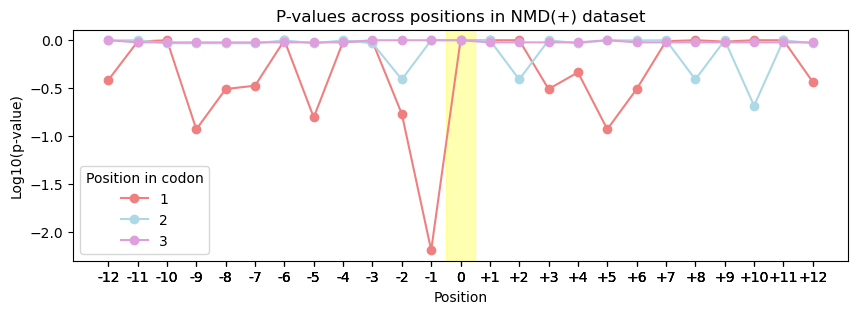

In [58]:
plt.figure(figsize=(10, 3))
#colors = ['#C8A2C8', '#B0E0E6', '#FFB6C1']
colors = ['lightcoral', 'lightblue', 'plum']

for positions, p_values, color in zip(positions_list, p_values_list, colors):
    plt.plot(positions, np.log10(p_values), marker='o', linestyle='-', color=color)

plt.title('P-values across positions in NMD(+) dataset')
plt.xlabel('Position')
plt.ylabel('Log10(p-value)')
plt.grid(False)
plt.legend(['1', '2', '3'], title='Position in codon')

all_positions = [pos for sublist in positions_list for pos in sublist]
plt.xticks(all_positions, [str(pos) if pos == 0 else f"{pos}" if pos < 0 else f"+{pos}" for pos in all_positions])

plt.axvspan(-0.5, 0.5, color='yellow', alpha=0.3)

plt.savefig('images/p_values_nmd_undergo_plot_wo_in_clinvar.png')
plt.show()

## 8. Relationship between the significance of a variant and its position in a codon¶

In [59]:
pat_nmd_undergo_final.loc[:, 'Significance'] = 'pathogenic'
ben_nmd_undergo_final.loc[:, 'Significance'] = 'benign'

In [60]:
all_nmd_undergo_final = pd.concat([pat_nmd_undergo_final, ben_nmd_undergo_final], ignore_index=True)

In [61]:
all_nmd_undergo_final = all_nmd_undergo_final.loc[all_nmd_undergo_final['Codon_position'] != 'No_stop']

In [62]:
all_nmd_undergo_final.to_csv('data/all_nmd_undergo_final_wo_in_clinvar.csv', index=False)

In [63]:
cross_tab_undergo = pd.crosstab(all_nmd_undergo_final['Significance'], all_nmd_undergo_final['Codon_position'])
print(cross_tab_undergo)

Codon_position     1    2    3
Significance                  
benign          2389  301  322
pathogenic      1906  509  597


In [64]:
chi2_undergo, p_value_undergo, _, _ = chi2_contingency(cross_tab_undergo)
print(f"Chi-squared value: {chi2_undergo}")
print(f"P-value: {p_value_undergo}")

Chi-squared value: 190.01929330265042
P-value: 5.468078387420359e-42


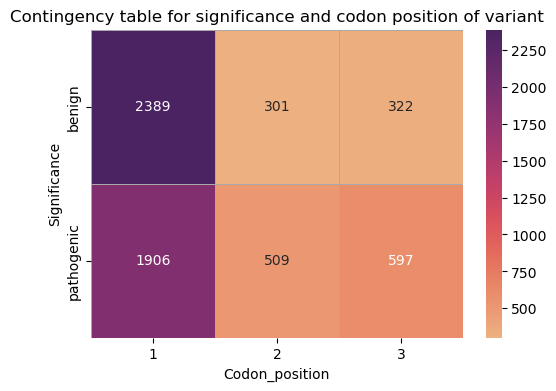

In [65]:
plt.figure(figsize=(6, 4))
sns.heatmap(cross_tab_undergo, annot=True, cmap='flare', fmt='d', cbar=True, linewidths=0.5, linecolor='darkgrey')
plt.title('Contingency table for significance and codon position of variant')
plt.xlabel('Codon_position')
plt.ylabel('Significance')
plt.show()


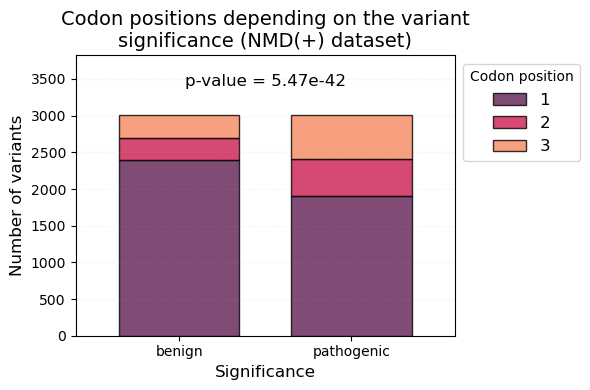

In [66]:
palette = sns.color_palette("rocket", len(cross_tab_undergo.columns))

ax = cross_tab_undergo.plot(kind='bar', stacked=True, alpha=0.8, edgecolor='black', linewidth=1, width=0.7, color=palette, figsize=(6, 4))

plt.title('Codon positions depending on the variant\nsignificance (NMD(+) dataset)', fontsize=14)
plt.xlabel('Significance', fontsize=12)
plt.ylabel('Number of variants', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Codon position', fontsize=12, bbox_to_anchor=(1, 1), loc='upper left')
plt.ylim(top=cross_tab_undergo.max().max() * 1.6)
plt.text(0.5, 3400, f'p-value = {format(p_value_undergo, '.2e')}', fontsize=12, ha='center')
plt.grid(True, axis='y', linestyle='--', alpha=0.1)
plt.tight_layout()

plt.savefig('images/codon_positions_hist_undergo_wo_in_clinvar.png', dpi=300)

plt.show()